In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Cargar el dataset
california = fetch_california_housing()

#Leer el dataset
data_df = pd.DataFrame(california.data, columns= california.feature_names)
data_df["MedHouseVal"] = california.target

In [3]:
#Tipo de datos de cada columna
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
#Número de datos faltantes por variable
data_df.isna().sum().sort_values()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

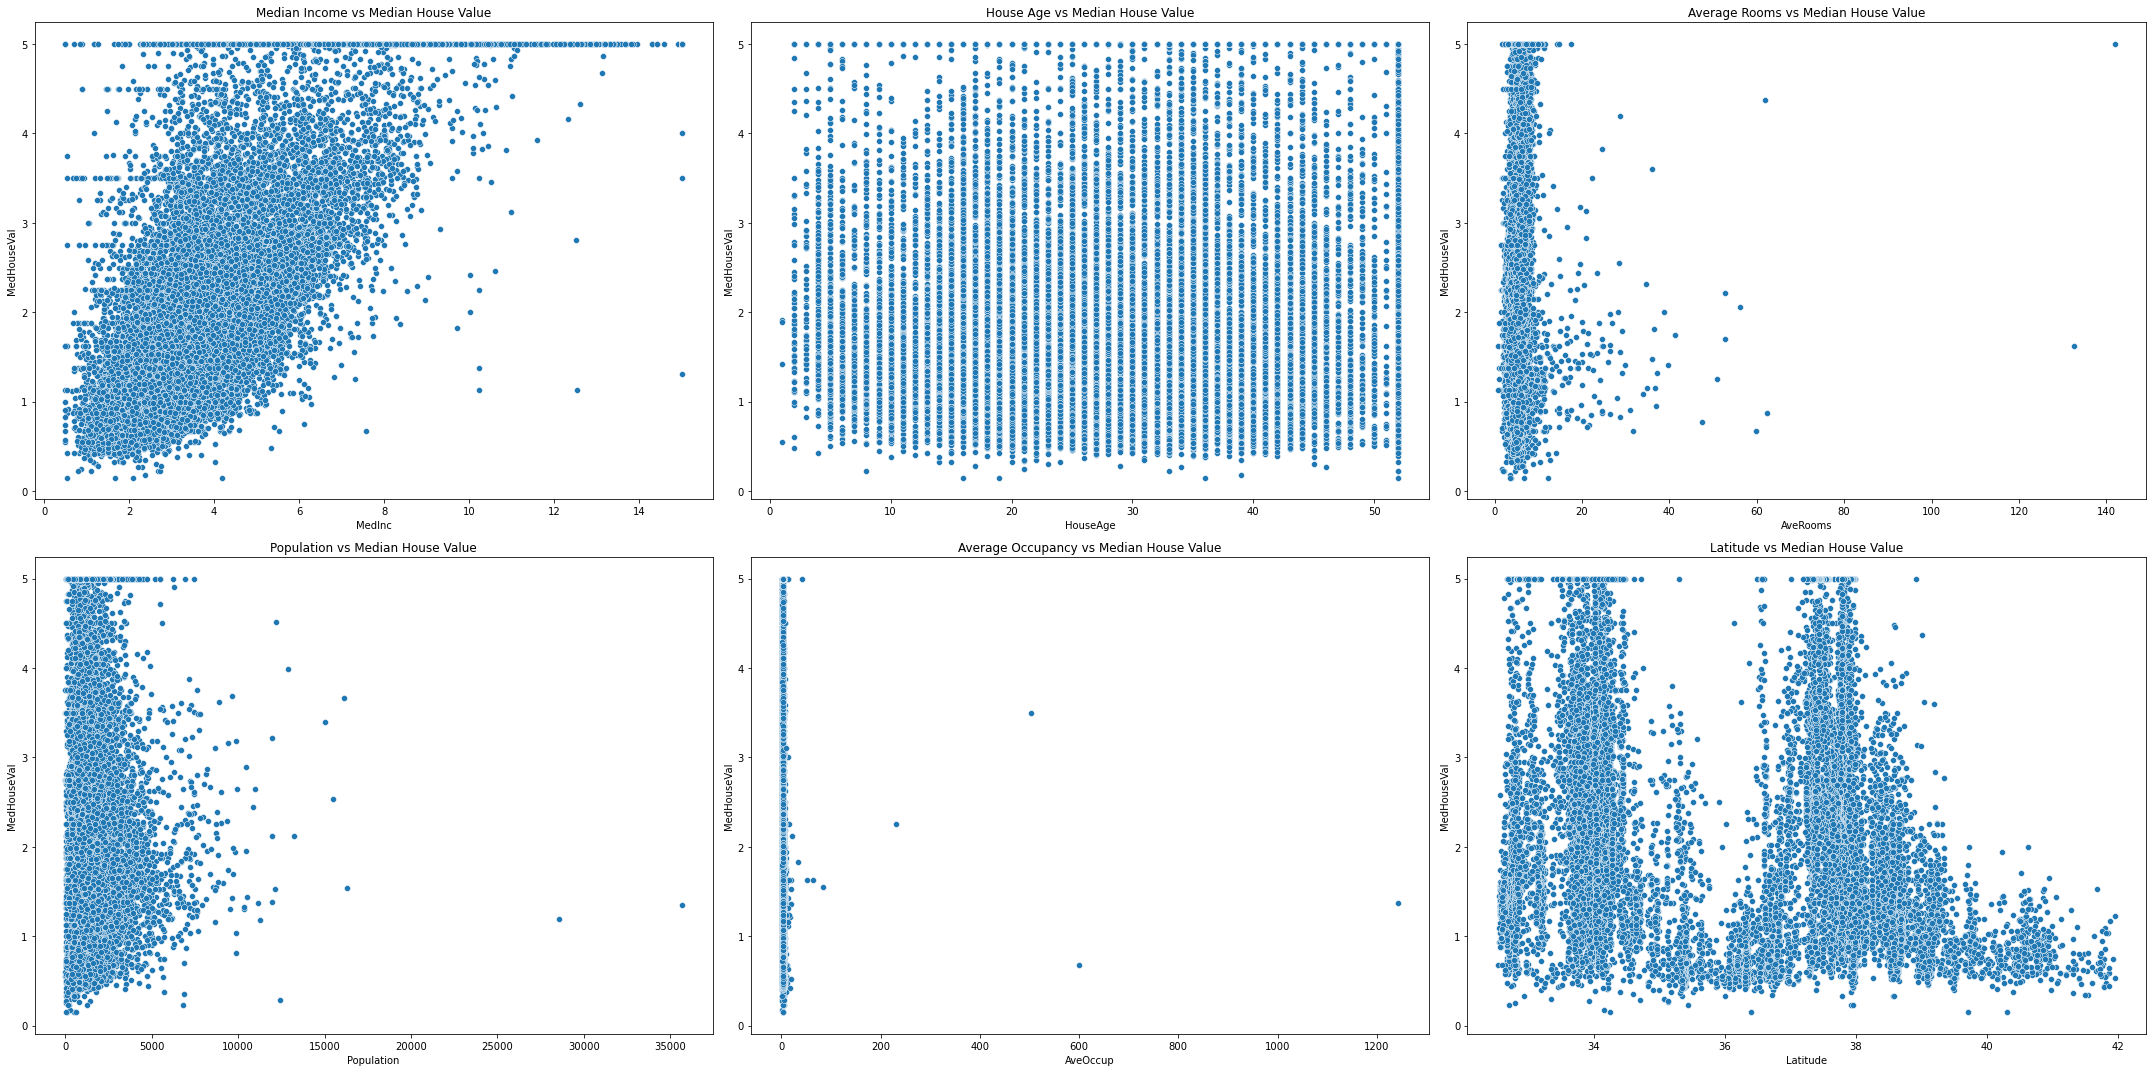

In [5]:
# Graficar algunas características contra el valor de la vivienda
plt.figure(figsize=(30, 15))

plt.subplot(2, 3, 1)
sns.scatterplot(x='MedInc', y='MedHouseVal', data=data_df)
plt.title('Median Income vs Median House Value')

plt.subplot(2, 3, 2)
sns.scatterplot(x='HouseAge', y='MedHouseVal', data=data_df)
plt.title('House Age vs Median House Value')

plt.subplot(2, 3, 3)
sns.scatterplot(x='AveRooms', y='MedHouseVal', data=data_df)
plt.title('Average Rooms vs Median House Value')

plt.subplot(2, 3, 4)
sns.scatterplot(x='Population', y='MedHouseVal', data=data_df)
plt.title('Population vs Median House Value')

plt.subplot(2, 3, 5)
sns.scatterplot(x='AveOccup', y='MedHouseVal', data=data_df)
plt.title('Average Occupancy vs Median House Value')

plt.subplot(2, 3, 6)
sns.scatterplot(x='Latitude', y='MedHouseVal', data=data_df)
plt.title('Latitude vs Median House Value')

plt.tight_layout()
plt.show()

In [6]:
X = data_df[["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population", "AveOccup", "Latitude", "Longitude"]].values
#print(X)

y = data_df["MedHouseVal"].values
#print(y)

In [7]:
#Dividir datos para entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#X_train
y_train

array([1.03 , 3.821, 1.726, ..., 2.221, 2.835, 3.25 ])

In [14]:
# Escalar las características 
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

print(X_test)
print(X_test_scaled)

[[   1.6812       25.            4.19220056 ...    3.87743733
    36.06       -119.01      ]
 [   2.5313       30.            5.03938356 ...    2.67979452
    35.14       -119.46      ]
 [   3.4801       52.            3.97715472 ...    1.36033229
    37.8        -122.44      ]
 ...
 [   9.2298       25.            7.23767606 ...    2.79049296
    37.31       -122.05      ]
 [   2.785        36.            5.28902954 ...    2.58860759
    36.77       -119.76      ]
 [   3.5521       17.            3.98883929 ...    3.72991071
    34.22       -118.37      ]]
[[-1.15508475 -0.28632369 -0.52068576 ...  0.06740798  0.1951
   0.28534728]
 [-0.70865905  0.11043502 -0.16581537 ... -0.03602975 -0.23549054
   0.06097472]
 [-0.21040155  1.85617335 -0.61076476 ... -0.14998876  1.00947776
  -1.42487026]
 ...
 [ 2.80902421 -0.28632369  0.75501156 ... -0.02646898  0.78014149
  -1.23041404]
 [-0.57542978  0.58654547 -0.06124296 ... -0.04390537  0.52740357
  -0.08860699]
 [-0.17259111 -0.92113763 -0.6

In [15]:
#Entrenar el modelo MLPRegressor
mlp = MLPRegressor(hidden_layer_sizes=(100,100), max_iter=1000, alpha=0.001, random_state=42)
mlp.fit(X_train_scaled, y_train)

MLPRegressor(alpha=0.001, hidden_layer_sizes=(100, 100), max_iter=1000,
             random_state=42)

In [16]:
#Realizar predicciones con los datos de prueba
y_pred = mlp.predict(X_test_scaled)

#print(y_pred)
#print(y_test)

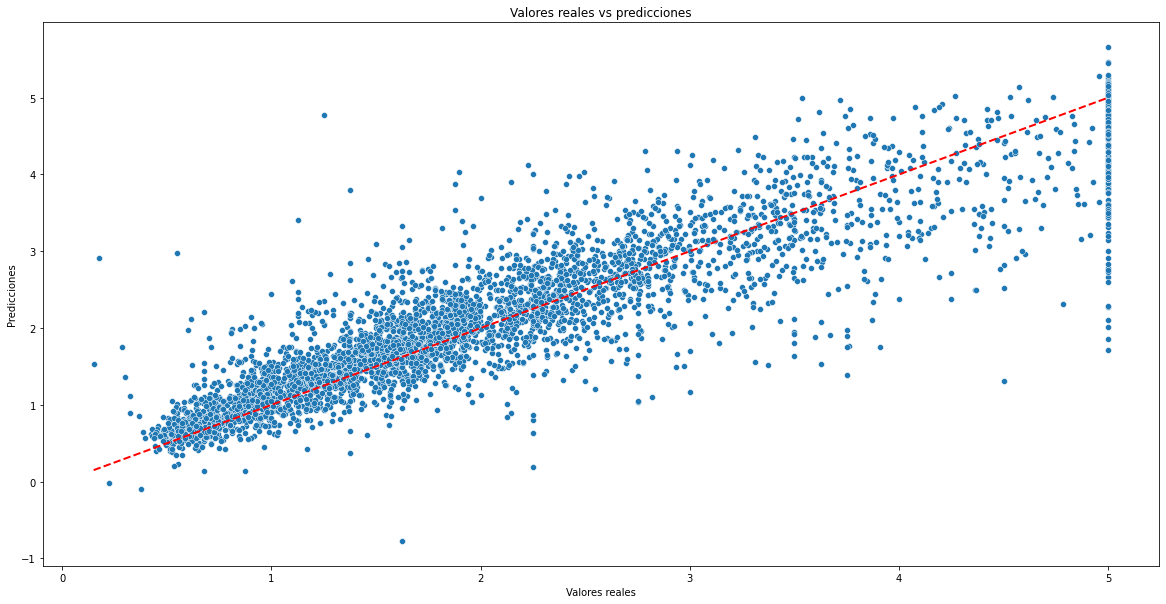

In [17]:
#Visualizar los datos

plt.figure(figsize=(20, 10))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Valores reales vs predicciones")
plt.show()

In [18]:
#Evaluar el rendimiento del modelo
mse = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse:.2f}")

r2 = r2_score(y_test, y_pred)
print(f"R2: {r2:.2f}")


MSE: 0.26
R2: 0.80
